In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir = "/content/drive/MyDrive/Garbage classification dataset"


In [ ]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
#!pip install tensorflow matplotlib scikit-learn

import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, optimizers
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:



classes = os.listdir(data_dir)

class_counts = {}

for cls in classes:
    class_path = os.path.join(data_dir, cls)
    num_images = len(os.listdir(class_path))
    class_counts[cls] = num_images

print(class_counts)

{'plastic': 482, 'paper': 594, 'trash': 137, 'glass': 501, 'cardboard': 403, 'metal': 410}


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Garbage classification dataset"))


['plastic', 'paper', 'trash', 'glass', 'cardboard', 'metal']


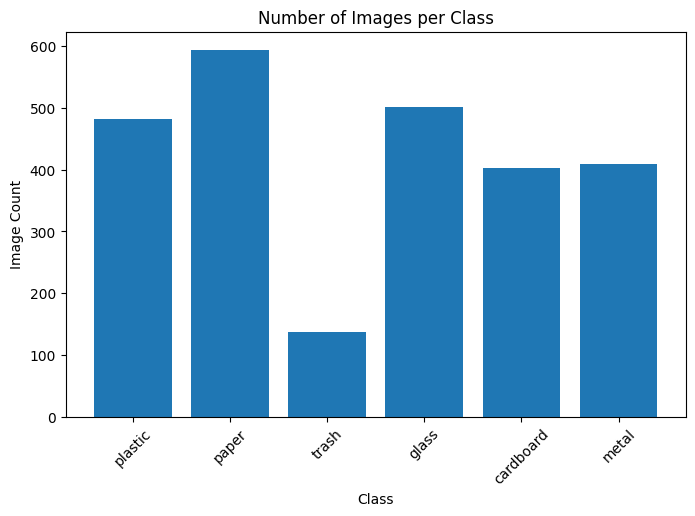

{'plastic': 482,
 'paper': 594,
 'trash': 137,
 'glass': 501,
 'cardboard': 403,
 'metal': 410}

In [ ]:
import os
import matplotlib.pyplot as plt


classes = os.listdir(data_dir)

counts = {}
for cls in classes:
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        counts[cls] = len(os.listdir(folder))

# Plot class distribution
plt.figure(figsize=(8, 5))
plt.bar(counts.keys(), counts.values())
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Image Count")
plt.xticks(rotation=45)
plt.show()

counts


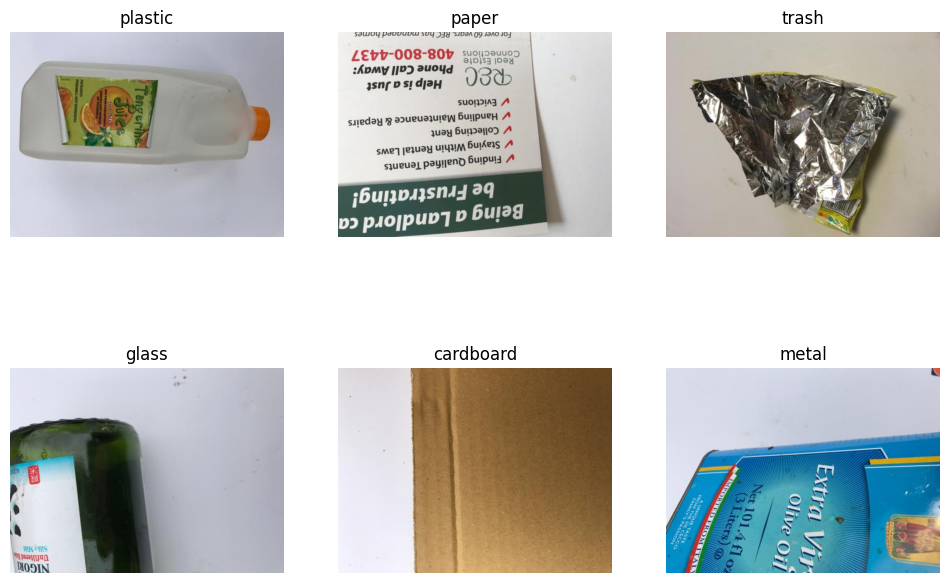

In [ ]:
import cv2
import random

plt.figure(figsize=(12, 8))

i = 1
for cls in classes:
    folder = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
    i += 1

plt.show()


In [ ]:
from PIL import Image
import os


classes = os.listdir(data_dir)

for cls in classes:
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        img_name = os.listdir(folder)[0]
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        print(f"{cls} → {img.size}")


plastic → (512, 384)
paper → (512, 384)
trash → (512, 384)
glass → (512, 384)
cardboard → (512, 384)
metal → (512, 384)


In [ ]:
from PIL import Image
import os

sizes = set()

for cls in os.listdir(data_dir):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        for img_name in os.listdir(folder)[:20]:  # check first 20 images per class
            try:
                img = Image.open(os.path.join(folder, img_name))
                sizes.add(img.size)
            except:
                pass

print("Unique image sizes found:", sizes)


Unique image sizes found: {(512, 384)}


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/Garbage classification dataset/plastic")[:10])


['plastic123.jpg', 'plastic122.jpg', 'plastic111.jpg', 'plastic100.jpg', 'plastic113.jpg', 'plastic107.jpg', 'plastic116.jpg', 'plastic106.jpg', 'plastic12.jpg', 'plastic112.jpg']




```
`# This is formatted as code`
```

Pixel Intensity Analysis

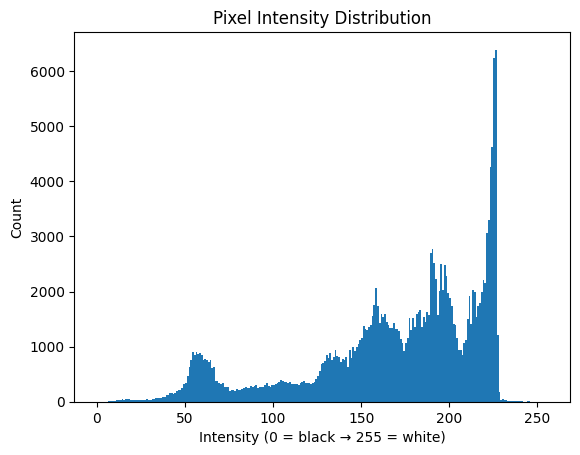

In [ ]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/drive/MyDrive/Garbage classification dataset//plastic/plastic236.jpg")   # use a valid filename
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.hist(gray.ravel(), bins=256, range=(0, 256))
plt.title("Pixel Intensity Distribution")
plt.xlabel("Intensity (0 = black → 255 = white)")
plt.ylabel("Count")
plt.show()




```
# This is formatted as code
```

pixel internsity per class

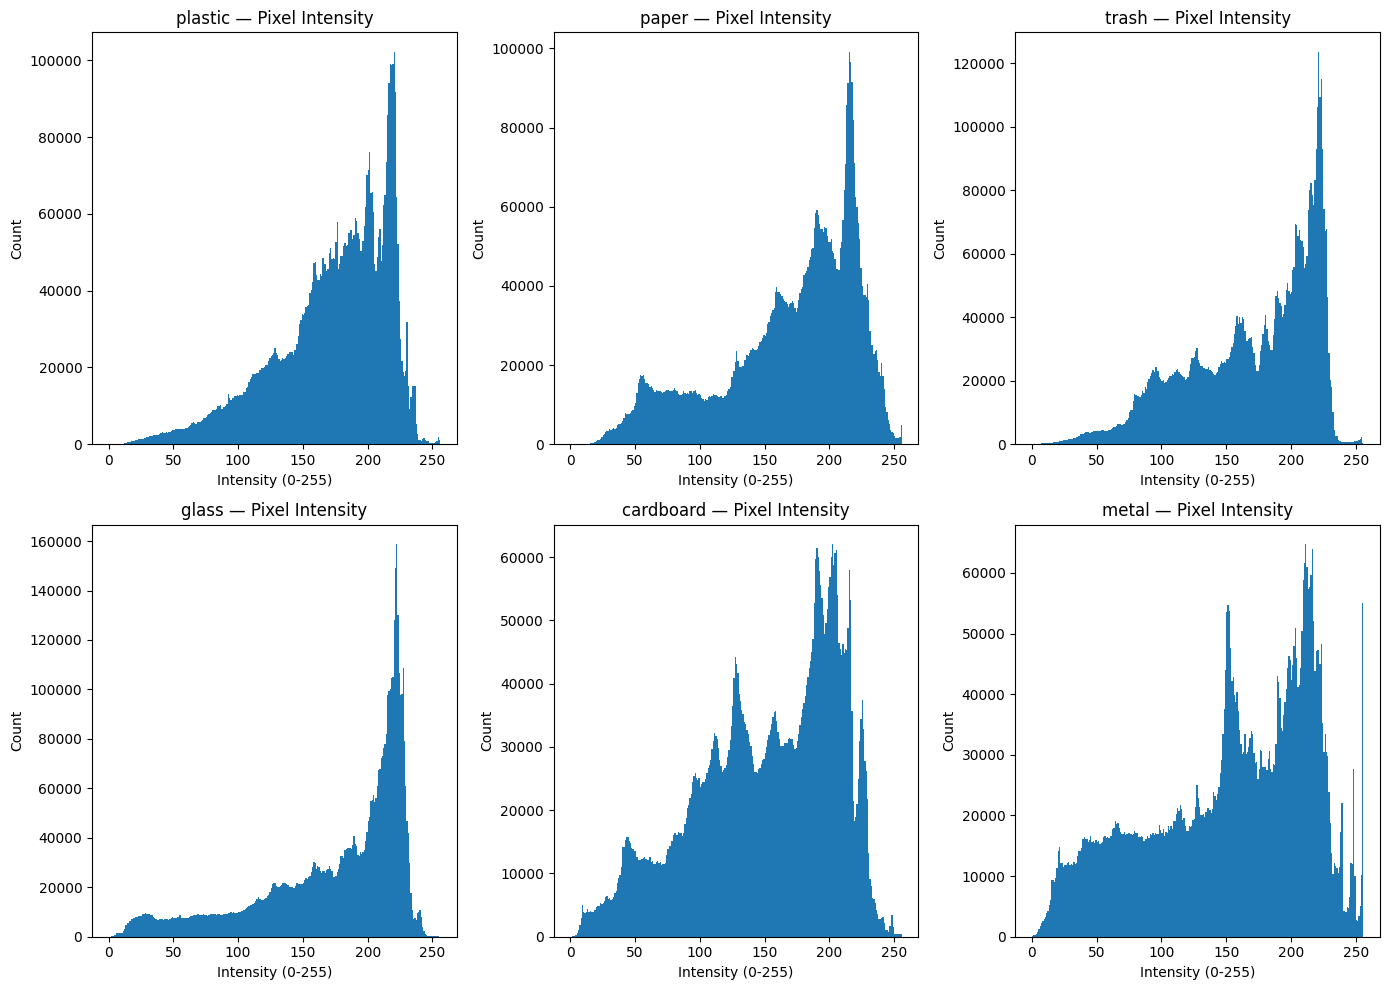

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image

classes = os.listdir(data_dir)

plt.figure(figsize=(14, 10))

for idx, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        intensities = []
        for img_name in os.listdir(folder)[:30]:
            try:
                img = cv2.imread(os.path.join(folder, img_name))
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                intensities.extend(gray.ravel())
            except:
                pass

        plt.subplot(2, 3, idx + 1)
        plt.hist(intensities, bins=256, range=(0, 256))
        plt.title(f"{cls} — Pixel Intensity")
        plt.xlabel("Intensity (0-255)")
        plt.ylabel("Count")

plt.tight_layout()
plt.show()


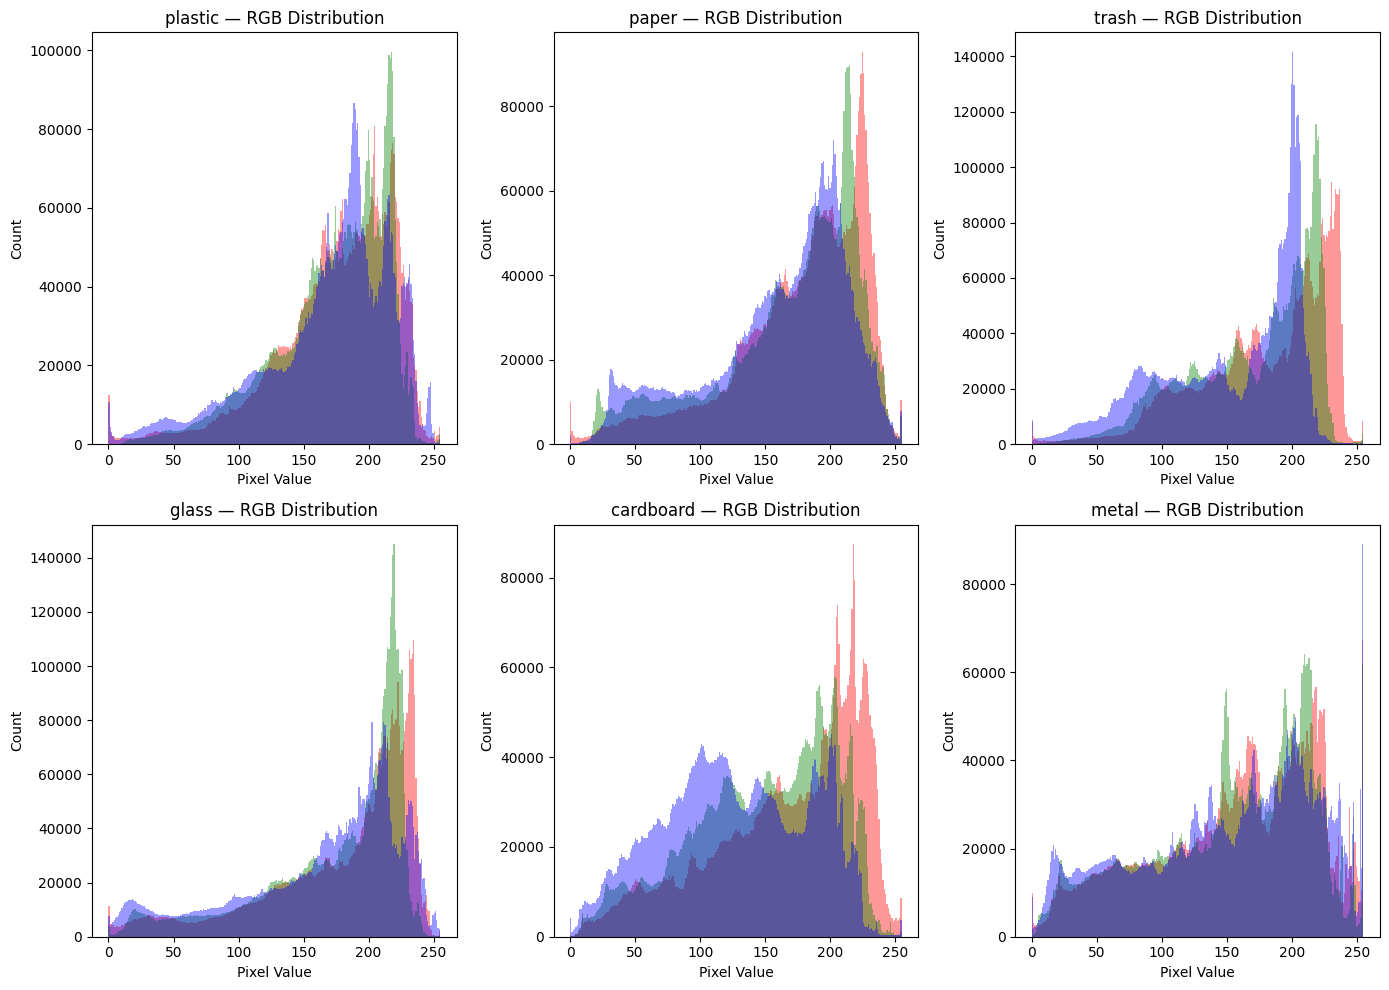

In [ ]:
plt.figure(figsize=(14, 10))

for idx, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    if os.path.isdir(folder):
        reds, greens, blues = [], [], []
        for img_name in os.listdir(folder)[:30]:
            try:
                img = cv2.imread(os.path.join(folder, img_name))
                b, g, r = cv2.split(img)
                reds.extend(r.ravel())
                greens.extend(g.ravel())
                blues.extend(b.ravel())
            except:
                pass

        plt.subplot(2, 3, idx + 1)
        plt.hist(reds, bins=256, color='red', alpha=0.4)
        plt.hist(greens, bins=256, color='green', alpha=0.4)
        plt.hist(blues, bins=256, color='blue', alpha=0.4)
        plt.title(f"{cls} — RGB Distribution")
        plt.xlabel("Pixel Value")
        plt.ylabel("Count")

plt.tight_layout()
plt.show()


All classes have a lot of bright pixels (peaks near 180–240)

This means images are mostly bright / well-lit, not dark

Paper & Plastic look very similar

Their RGB histograms overlap heavily.

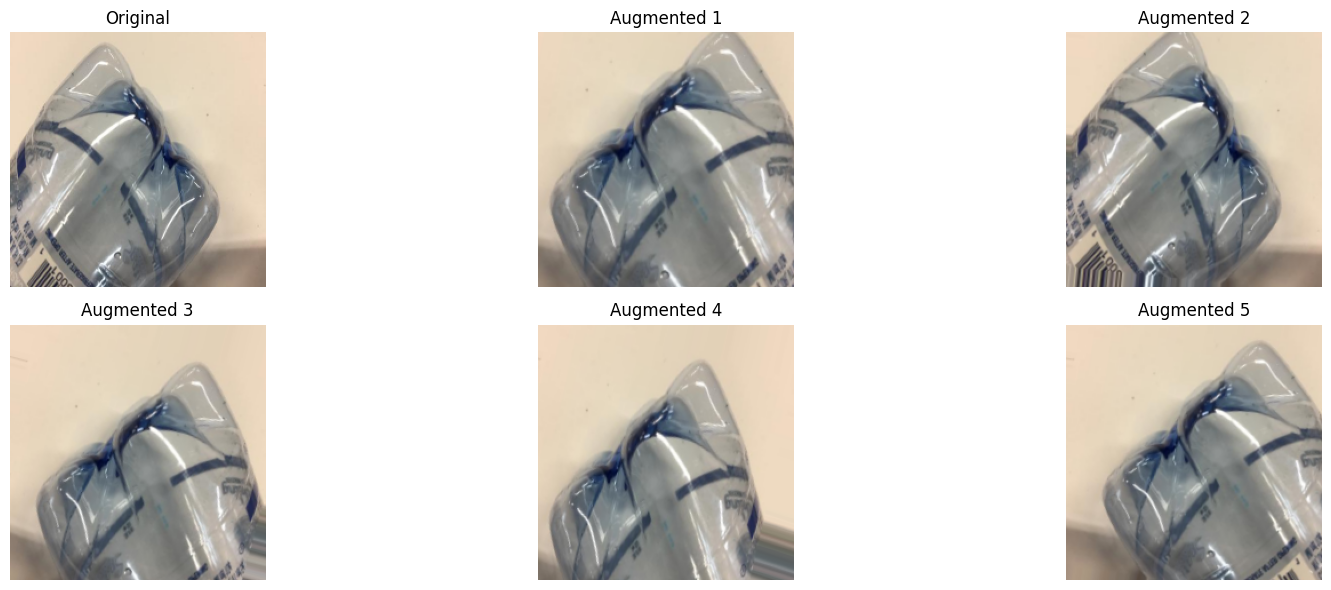

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

data_dir = "/content/drive/MyDrive/Garbage classification dataset"
class_name = "plastic"
img_name = os.listdir(os.path.join(data_dir, class_name))[0]
img_path = os.path.join(data_dir, class_name, img_name)

# Load original
original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Resize to generator input size
resized = cv2.resize(original, (224, 224))

# Generate 5 augmented versions
aug_iter = train_gen.flow(np.expand_dims(resized, 0), batch_size=1)
aug_images = [(next(aug_iter)[0] * 255).astype(np.uint8) for _ in range(5)]

# Display original + augmentations
plt.figure(figsize=(18, 6))

plt.subplot(2, 3, 1)
plt.imshow(resized)
plt.title("Original")
plt.axis("off")

for i in range(5):
    plt.subplot(2, 3, i + 2)
    plt.imshow(aug_images[i])
    plt.title(f"Augmented {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


RESNET50


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input as preprocess_input_resnet
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
from sklearn.metrics import confusion_matrix


In [ ]:
train_gen1 = ImageDataGenerator(
    preprocessing_function=preprocess_input_resnet,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen1 = ImageDataGenerator(
    preprocessing_function=preprocess_input_resnet,
    validation_split=0.2
)

train_data1 = train_gen1.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_data1 = val_gen1.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False

)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
train_labels = train_data1.classes
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(1.04437564499484), 1: np.float64(0.8412302576891105), 2: np.float64(1.0284552845528456), 3: np.float64(0.7086834733893558), 4: np.float64(0.8739205526770294), 5: np.float64(3.066666666666667)}


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
resnet.trainable = False  # freeze pretrained layers

# Build Model
model = Sequential([
    resnet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(train_data1.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_data1,
    validation_data=test_data1,
    epochs=20,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)

print("Training completed!")


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

pred = model.predict(test_data1)
y_pred = np.argmax(pred, axis=1)
y_true = test_data1.classes

#print(classification_report(y_true, y_pred, target_names=list(test_data.class_indices.keys())))
cm = confusion_matrix(y_true, y_pred)
cm
accuracy = np.mean(y_pred == y_true)
print("Accuracy:", accuracy)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 389ms/step
Accuracy: 0.8449304174950298


Fine tuning

In [ ]:
resnet.trainable = True

# keep early layers frozen (good for transfer learning)
for layer in resnet.layers[:-120]:
    layer.trainable = False


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_finetune = model.fit(
    train_data1,
    validation_data=test_data1,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stop]
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - accuracy: 0.8412 - loss: 0.4926 - val_accuracy: 0.8151 - val_loss: 0.5226
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 611ms/step - accuracy: 0.9114 - loss: 0.2454 - val_accuracy: 0.8131 - val_loss: 0.5063
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 612ms/step - accuracy: 0.9334 - loss: 0.1971 - val_accuracy: 0.8231 - val_loss: 0.4817
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 608ms/step - accuracy: 0.9391 - loss: 0.1507 - val_accuracy: 0.8270 - val_loss: 0.4870
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 609ms/step - accuracy: 0.9517 - loss: 0.1195 - val_accuracy: 0.8390 - val_loss: 0.4735
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 603ms/step - accuracy: 0.9646 - loss: 0.1137 - val_accuracy: 0.8290 - val_loss: 0.4774
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.9738 - loss: 0.0854

64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 615ms/step - accuracy: 0.9738 - loss: 0.0855 - val_accuracy: 0.8469 - val_loss: 0.4554
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 545ms/step - accuracy: 0.9687 - loss: 0.0874

64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 607ms/step - accuracy: 0.9687 - loss: 0.0874 - val_accuracy: 0.8489 - val_loss: 0.4359
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 38s 586ms/step - accuracy: 0.9828 - loss: 0.0651 - val_accuracy: 0.8449 - val_loss: 0.4747
Epoch 10/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 39s 603ms/step - accuracy: 0.9888 - loss: 0.0457 - val_accuracy: 0.8449 - val_loss: 0.4718


In [ ]:
test_data1.reset()

pred1 = model.predict(test_data1)
y_pred1 = np.argmax(pred1, axis=1)
accuracy1 = np.mean(y_pred1 == test_data1.classes)

print("New Accuracy after fine-tuning:", accuracy1)


16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 405ms/step
New Accuracy after fine-tuning: 0.8489065606361829


16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step


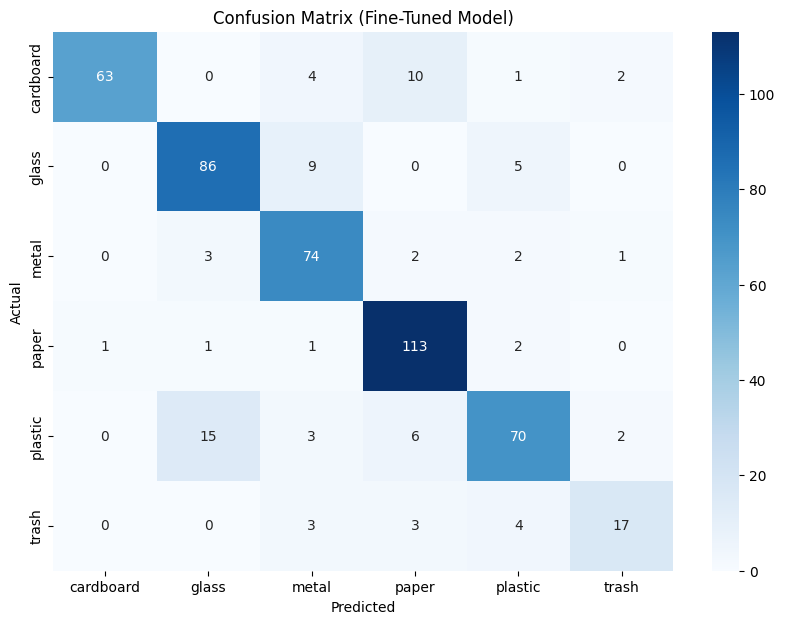

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Reset generator
#test_data1.reset()

# Predictions
pred1 = model.predict(test_data1)
y_pred1 = np.argmax(pred1, axis=1)
y_true1 = test_data1.classes

# Confusion matrix
cm_resnet= confusion_matrix(y_true1, y_pred1)

# Class names
class_names = list(test_data1.class_indices.keys())

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Fine-Tuned Model)")
plt.show()


In [ ]:
model.save("resnet50_model.keras")


NameError: name 'model' is not defined

In [ ]:
from google.colab import files
files.download("resnet50_model.keras")

FileNotFoundError: Cannot find file: resnet50_model.keras

In [ ]:
model.save("/content/drive/MyDrive/resnet50_model.keras")


In [ ]:
from google.colab import files
files.download("resnet50_model.keras")


MOBILENET

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data = train_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

test_data = val_gen.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False   # IMPORTANT for accurate evaluation
)


In [ ]:
labels = train_data.classes
weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(weights_array))
class_weights


In [ ]:
mobilenet = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

mobilenet.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_m = Sequential([
    mobilenet,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(train_data.num_classes, activation='softmax')
])

model_m.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_m.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history_m = model_m.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True),
        ModelCheckpoint("mobilenet_best.h5", save_best_only=True)
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 646ms/step - accuracy: 0.3825 - loss: 1.7508

64/64 ━━━━━━━━━━━━━━━━━━━━ 80s 968ms/step - accuracy: 0.3841 - loss: 1.7455 - val_accuracy: 0.5328 - val_loss: 1.1893
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.6410 - loss: 1.0592

64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 525ms/step - accuracy: 0.6411 - loss: 1.0589 - val_accuracy: 0.5785 - val_loss: 1.1243
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.6841 - loss: 0.8847

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 536ms/step - accuracy: 0.6842 - loss: 0.8848 - val_accuracy: 0.6183 - val_loss: 1.0447
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.6922 - loss: 0.8564

64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 556ms/step - accuracy: 0.6923 - loss: 0.8563 - val_accuracy: 0.6382 - val_loss: 1.0279
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.7311 - loss: 0.7616

64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 496ms/step - accuracy: 0.7309 - loss: 0.7622 - val_accuracy: 0.6382 - val_loss: 0.9840
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step - accuracy: 0.7194 - loss: 0.7629

64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 522ms/step - accuracy: 0.7195 - loss: 0.7627 - val_accuracy: 0.6481 - val_loss: 0.9623
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 503ms/step - accuracy: 0.7433 - loss: 0.7080 - val_accuracy: 0.6461 - val_loss: 0.9889
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 519ms/step - accuracy: 0.7472 - loss: 0.6487 - val_accuracy: 0.6700 - val_loss: 0.9807
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.7850 - loss: 0.6029

64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 506ms/step - accuracy: 0.7848 - loss: 0.6031 - val_accuracy: 0.6640 - val_loss: 0.9262
Epoch 10/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 535ms/step - accuracy: 0.7846 - loss: 0.5947 - val_accuracy: 0.6541 - val_loss: 0.9913


In [ ]:
test_data.reset()

pred_m = model_m.predict(test_data)
y_pred_m = np.argmax(pred_m, axis=1)
y_true_m = test_data.classes

accuracy_m = np.mean(y_pred_m == y_true_m)
print("Final MobileNet Accuracy:", accuracy_m)


16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 415ms/step
Final MobileNet Accuracy: 0.6640159045725647


Fine tuning

In [ ]:
mobilenet.trainable = True

for layer in mobilenet.layers[:-100]:
    layer.trainable = False




In [ ]:
model_m.compile(
    optimizer=Adam(1e-5),   # small LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_m_ft = model_m.fit(
    train_data,
    validation_data=test_data,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True)
    ]
)


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 66s 761ms/step - accuracy: 0.8411 - loss: 0.3932 - val_accuracy: 0.6660 - val_loss: 1.0062
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.8464 - loss: 0.4079 - val_accuracy: 0.6680 - val_loss: 1.0047
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 518ms/step - accuracy: 0.8441 - loss: 0.3937 - val_accuracy: 0.6759 - val_loss: 0.9708
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 498ms/step - accuracy: 0.8542 - loss: 0.3754 - val_accuracy: 0.6759 - val_loss: 0.9622
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 511ms/step - accuracy: 0.8431 - loss: 0.4076 - val_accuracy: 0.6759 - val_loss: 0.9514
Epoch 6/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.8618 - loss: 0.3764 - val_accuracy: 0.6799 - val_loss: 0.9451
Epoch 7/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 528ms/step - accuracy: 0.8696 - loss: 0.3600 - val_accuracy: 0.6879 - val_loss: 0.9268
Epoch 8/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 42s 546ms/step - accuracy: 0.8627 - loss: 0.3373 - val_accu

In [ ]:
test_data.reset()

pred_m = model_m.predict(test_data)
y_pred_m = np.argmax(pred_m, axis=1)
y_true_m = test_data.classes

accuracy_m = np.mean(y_pred_m == y_true_m)
print("Final MobileNet Accuracy:", accuracy_m)


16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 395ms/step
Final MobileNet Accuracy: 0.6938369781312127


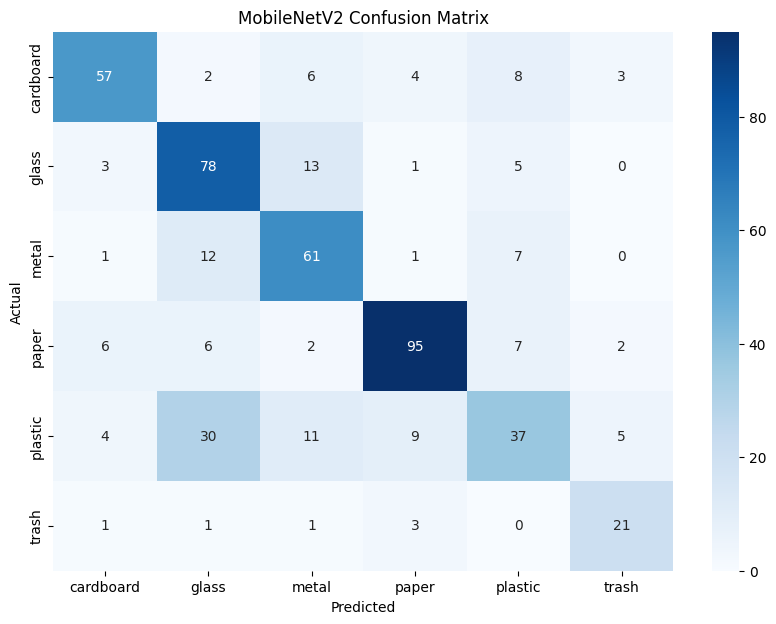

In [ ]:
cm_mob = confusion_matrix(y_true_m, y_pred_m)

plt.figure(figsize=(10,7))
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data.class_indices.keys(),
            yticklabels=test_data.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()


EFFICIENTNETB0


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_eff
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
train_gen_e = ImageDataGenerator(
    preprocessing_function=preprocess_input_eff,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen_e = ImageDataGenerator(
    preprocessing_function=preprocess_input_eff,
    validation_split=0.2
)

train_data_e = train_gen_e.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

test_data_e = val_gen_e.flow_from_directory(
    data_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
labels_e = train_data_e.classes
weights_array_e = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels_e),
    y=labels_e
)
class_weights_e = dict(enumerate(weights_array_e))
class_weights_e


{0: np.float64(1.04437564499484),
 1: np.float64(0.8412302576891105),
 2: np.float64(1.0284552845528456),
 3: np.float64(0.7086834733893558),
 4: np.float64(0.8739205526770294),
 5: np.float64(3.066666666666667)}

In [ ]:
effnet = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

effnet.trainable = False


In [ ]:
model_e = Sequential([
    effnet,
    GlobalAveragePooling2D(),
    Dense(512, activation="relu"),      # EfficientNet benefits from 512
    Dropout(0.3),
    Dense(train_data_e.num_classes, activation="softmax")
])

model_e.compile(
    optimizer=Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_e.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,708,521 (17.96 MB)

 Trainable params: 658,950 (2.51 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history_e = model_e.fit(
    train_data_e,
    validation_data=test_data_e,
    epochs=12,
    class_weight=class_weights_e,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True),
        ModelCheckpoint("efficientnet_best.h5", save_best_only=True)
    ]
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.6680 - loss: 0.9530

64/64 ━━━━━━━━━━━━━━━━━━━━ 74s 849ms/step - accuracy: 0.6695 - loss: 0.9487 - val_accuracy: 0.8231 - val_loss: 0.5064
Epoch 2/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 518ms/step - accuracy: 0.8912 - loss: 0.3045 - val_accuracy: 0.8191 - val_loss: 0.5526
Epoch 3/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.9169 - loss: 0.2486

64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.9171 - loss: 0.2482 - val_accuracy: 0.8489 - val_loss: 0.4422
Epoch 4/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 34s 531ms/step - accuracy: 0.9616 - loss: 0.1393 - val_accuracy: 0.8429 - val_loss: 0.4477
Epoch 5/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 504ms/step - accuracy: 0.9571 - loss: 0.1106 - val_accuracy: 0.8509 - val_loss: 0.4534
Epoch 6/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 499ms/step - accuracy: 0.9692 - loss: 0.1012 - val_accuracy: 0.8489 - val_loss: 0.4544
Epoch 7/12
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 508ms/step - accuracy: 0.9698 - loss: 0.0857 - val_accuracy: 0.8489 - val_loss: 0.4898


In [ ]:
effnet.trainable = True

for layer in effnet.layers[:-80]:

    layer.trainable = False


In [ ]:
model_e.compile(
    optimizer=Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [ ]:
history_e_ft = model_e.fit(
    train_data_e,
    validation_data=test_data_e,
    epochs=15,
    class_weight=class_weights_e,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)]
)


Epoch 1/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 101s 986ms/step - accuracy: 0.7654 - loss: 0.7107 - val_accuracy: 0.8330 - val_loss: 0.4535
Epoch 2/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 500ms/step - accuracy: 0.8196 - loss: 0.5489 - val_accuracy: 0.8270 - val_loss: 0.4899
Epoch 3/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 35s 544ms/step - accuracy: 0.8484 - loss: 0.4999 - val_accuracy: 0.8330 - val_loss: 0.5082
Epoch 4/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 32s 502ms/step - accuracy: 0.8691 - loss: 0.4171 - val_accuracy: 0.8330 - val_loss: 0.5156
Epoch 5/15
64/64 ━━━━━━━━━━━━━━━━━━━━ 33s 520ms/step - accuracy: 0.8761 - loss: 0.3833 - val_accuracy: 0.8390 - val_loss: 0.5118


In [ ]:
test_data_e.reset()

pred_e = model_e.predict(test_data_e)
y_pred_e = np.argmax(pred_e, axis=1)
y_true_e = test_data_e.classes

accuracy_e = np.mean(y_pred_e == y_true_e)
print("Final EfficientNetB0 Accuracy:", accuracy_e)


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 548ms/step
Final EfficientNetB0 Accuracy: 0.8330019880715706


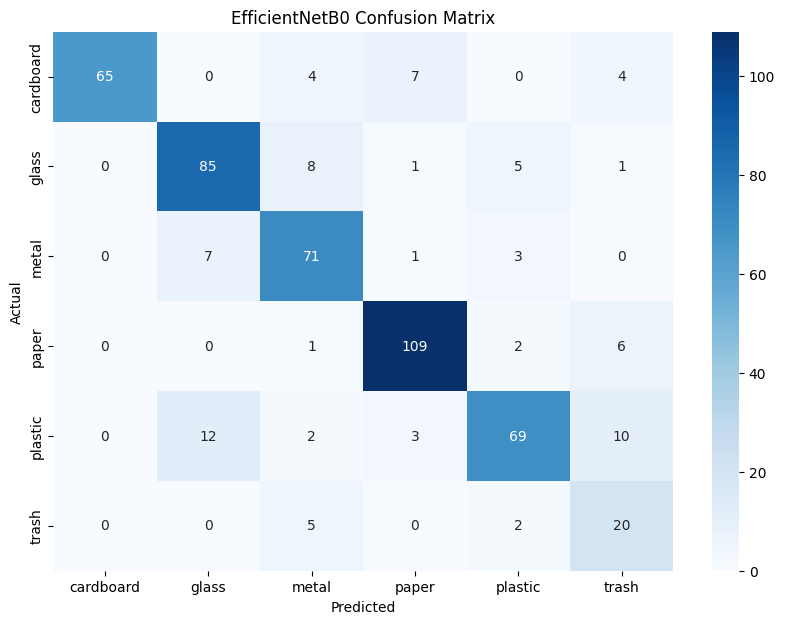

In [ ]:
cm = confusion_matrix(y_true_e, y_pred_e)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=test_data_e.class_indices.keys(),
            yticklabels=test_data_e.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()


EFFICIENTNETB3

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
train_gen_e3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

val_gen_e3 = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

train_data_e3 = train_gen_e3.flow_from_directory(
    data_dir,
    target_size=(300, 300),   # EfficientNetB3 expects 300x300
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_data_e3 = val_gen_e3.flow_from_directory(
    data_dir,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.


In [ ]:
labels_e3 = train_data_e3.classes
weights_array_e3 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels_e3),
    y=labels_e3
)
class_weights_e3 = dict(enumerate(weights_array_e3))
class_weights_e3


{0: np.float64(1.04437564499484),
 1: np.float64(0.8412302576891105),
 2: np.float64(1.0284552845528456),
 3: np.float64(0.7086834733893558),
 4: np.float64(0.8739205526770294),
 5: np.float64(3.066666666666667)}

In [ ]:
effnet3 = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_shape=(300, 300, 3)
)

effnet3.trainable = False


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model_e3 = Sequential([
    effnet3,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(train_data_e3.num_classes, activation='softmax')
])

model_e3.compile(
    optimizer=Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_e3.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,573,557 (44.15 MB)

 Trainable params: 790,022 (3.01 MB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [ ]:
history_e3 = model_e3.fit(
    train_data_e3,
    validation_data=test_data_e3,
    epochs=10,
    class_weight=class_weights_e3,
    callbacks=[
        EarlyStopping(patience=4, restore_best_weights=True),
        ModelCheckpoint("efficientnetB3_best.h5", save_best_only=True)
    ]
)



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6825 - loss: 0.9097

64/64 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6842 - loss: 0.9052 - val_accuracy: 0.8270 - val_loss: 0.4606
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 829ms/step - accuracy: 0.8868 - loss: 0.3097 - val_accuracy: 0.8350 - val_loss: 0.4621
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - accuracy: 0.9269 - loss: 0.2125

64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 823ms/step - accuracy: 0.9269 - loss: 0.2126 - val_accuracy: 0.8529 - val_loss: 0.4284
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 784ms/step - accuracy: 0.9355 - loss: 0.1918

64/64 ━━━━━━━━━━━━━━━━━━━━ 54s 841ms/step - accuracy: 0.9354 - loss: 0.1919 - val_accuracy: 0.8787 - val_loss: 0.3706
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 814ms/step - accuracy: 0.9505 - loss: 0.1515 - val_accuracy: 0.8648 - val_loss: 0.4183
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 816ms/step - accuracy: 0.9528 - loss: 0.1205 - val_accuracy: 0.8648 - val_loss: 0.4348
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 822ms/step - accuracy: 0.9639 - loss: 0.1010 - val_accuracy: 0.8628 - val_loss: 0.4291
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 52s 813ms/step - accuracy: 0.9602 - loss: 0.0983 - val_accuracy: 0.8588 - val_loss: 0.4321


In [ ]:
effnet3.trainable = True

for layer in effnet3.layers[:-80]:
    layer.trainable = False


In [ ]:
model_e3.compile(
    optimizer=Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history_e3_ft = model_e3.fit(
    train_data_e3,
    validation_data=test_data_e3,
    epochs=10,
    class_weight=class_weights_e3,
    callbacks=[EarlyStopping(patience=4, restore_best_weights=True)]
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8183 - loss: 0.5545 - val_accuracy: 0.8549 - val_loss: 0.4129
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 815ms/step - accuracy: 0.8659 - loss: 0.4208 - val_accuracy: 0.8330 - val_loss: 0.4444
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 828ms/step - accuracy: 0.9073 - loss: 0.2990 - val_accuracy: 0.8370 - val_loss: 0.4575
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 831ms/step - accuracy: 0.8997 - loss: 0.2901 - val_accuracy: 0.8449 - val_loss: 0.4572
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 859ms/step - accuracy: 0.8897 - loss: 0.2810 - val_accuracy: 0.8469 - val_loss: 0.4553


In [ ]:
test_data_e3.reset()

pred_e3 = model_e3.predict(test_data_e3)
y_pred_e3 = np.argmax(pred_e3, axis=1)
y_true_e3 = test_data_e3.classes

accuracy_e3 = np.mean(y_pred_e3 == y_true_e3)
print("Final EfficientNetB3 Accuracy:", accuracy_e3)


16/16 ━━━━━━━━━━━━━━━━━━━━ 27s 896ms/step
Final EfficientNetB3 Accuracy: 0.8548707753479126
